# 01 — Feature Engineering & Preprocessing Pipeline

**Goal:** Build the sklearn Pipeline (FeatureEngineer → ColumnTransformer) and validate it.
Establish a LinearRegression baseline RMSE. Save the fitted preprocessor.

**Outputs:**
- `outputs/models/preprocessor_linear.pkl`
- `outputs/models/preprocessor_tree.pkl`
- Baseline RMSE printed

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from src.features import FeatureEngineer, COLS_TO_DROP, ZERO_FILL_COLS
from src.pipeline import build_preprocessor, build_pipeline, NUMERIC_FEATURES, LOW_CARD_CATEGORICAL, TARGET_ENCODED_COLS
from src.evaluate import rmse, cv_score

DATA_DIR  = Path('../data')
MODEL_DIR = Path('../outputs/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Training Data

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

TARGET = 'resale_price'
X = train.drop(columns=[TARGET])
y = train[TARGET]

print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print(f'Target range: S${y.min():,.0f} – S${y.max():,.0f}')

X shape: (150634, 76)  |  y shape: (150634,)
Target range: S$150,000 – S$1,258,000


## 2. Feature Decisions from feature_profile.xlsx

The EDA notebook exported a `feature_profile.xlsx` with an `Action` column
(`Keep` / `Drop` / `Target`) for every raw column. We read it here so that
drop/keep decisions are driven by the profiling artifact, not hardcoded lists.

In [3]:
PROFILE_PATH = Path('../outputs/feature_profile.xlsx')
profile_df = pd.read_excel(PROFILE_PATH, sheet_name='Feature Profile')

drop_cols = profile_df[profile_df['Action'] == 'Drop']['Column'].tolist()
keep_cols = profile_df[profile_df['Action'] == 'Keep']['Column'].tolist()

print(f'Features to DROP ({len(drop_cols)}):')
for col in drop_cols:
    rationale = profile_df.loc[profile_df['Column'] == col, 'Rationale'].iloc[0]
    print(f'  {col:<35} {rationale}')

print(f'\nFeatures to KEEP ({len(keep_cols)}): {keep_cols}')

Features to DROP (25):
  id                                  Row identifier; no predictive value
  Tranc_YearMonth                     Redundant with Tranc_Year + Tranc_Month
  address                             Free text; replaced by block + street_name
  postal                              Replaced by Latitude / Longitude coordinates
  storey_range                        Replaced by mid_storey / max_floor_lvl → storey_ratio
  lower                               Derivable from storey_range; redundant
  upper                               Derivable from storey_range; redundant
  mid                                 Derivable from storey_range; mid_storey preferred
  full_flat_type                      Concatenation of flat_type + flat_model; redundant
  floor_area_sqft                     floor_area_sqm × 10.764; perfectly collinear
  year_completed                      Correlated with lease_commence_date; may be redundant
  residential                         Near-constant (almost all

In [4]:
# Verify src/features.py COLS_TO_DROP is aligned with the Excel
from src.features import COLS_TO_DROP

in_code_not_excel = sorted(set(COLS_TO_DROP) - set(drop_cols))
in_excel_not_code = sorted(set(drop_cols) - set(COLS_TO_DROP))

if in_code_not_excel:
    print(f'In COLS_TO_DROP but not in Excel: {in_code_not_excel}')
if in_excel_not_code:
    print(f'In Excel (Drop) but not in COLS_TO_DROP: {in_excel_not_code}')
if not in_code_not_excel and not in_excel_not_code:
    print('COLS_TO_DROP matches feature_profile.xlsx exactly.')

COLS_TO_DROP matches feature_profile.xlsx exactly.


## 3. Feature Engineering — Walkthrough

`FeatureEngineer` (in `src/features.py`) adds derived features and drops redundant columns.
Most logic is stateless, but `fit(X, y)` must be called with the target to compute
the `block_flat_psqm` lookup tables — sklearn Pipelines handle this automatically.

In [5]:
fe = FeatureEngineer()
fe.fit(X, y)  # required to compute block_flat_psqm lookup tables
X_fe = fe.transform(X)

print(f'Before FE: {X.shape[1]} columns')
print(f'After FE : {X_fe.shape[1]} columns')

new_cols = set(X_fe.columns) - set(X.columns)
dropped_cols = set(X.columns) - set(X_fe.columns)

print(f'\nNew features ({len(new_cols)}): {sorted(new_cols)}')
print(f'\nDropped features ({len(dropped_cols)}): {sorted(dropped_cols)}')

Before FE: 76 columns
After FE : 63 columns

New features (12): ['block_flat_psqm', 'cbd_dist_m', 'floor_area_log', 'hdb_tranc_age', 'mall_dist_log', 'mrt_dist_log', 'orchard_dist_m', 'remaining_lease', 'rental_density', 'total_rental_units', 'tranc_quarter', 'year_quarter']

Dropped features (25): ['Tranc_YearMonth', 'address', 'bus_stop_latitude', 'bus_stop_longitude', 'bus_stop_name', 'floor_area_sqft', 'full_flat_type', 'id', 'lower', 'mid', 'mrt_latitude', 'mrt_longitude', 'mrt_name', 'postal', 'pri_sch_latitude', 'pri_sch_longitude', 'pri_sch_name', 'residential', 'sec_sch_latitude', 'sec_sch_longitude', 'sec_sch_name', 'storey_range', 'upper', 'vacancy', 'year_completed']


## 4. ColumnTransformer Schema

Two preprocessors are built:
- **`mode='linear'`** — adds `StandardScaler` (required for LR, Ridge, Lasso, ElasticNet, KNN)
- **`mode='tree'`** — no scaling (GBR, XGBoost, LightGBM are scale-invariant)

In [6]:
# Show which columns go into each transformer group
print('=== NUMERIC FEATURES ===')
num_present = [c for c in NUMERIC_FEATURES if c in X_fe.columns]
print(f'  {len(num_present)} features: {num_present[:8]} ...')

print('\n=== LOW-CARDINALITY CATEGORICALS ===')
cat_present = [c for c in LOW_CARD_CATEGORICAL if c in X_fe.columns]
print(f'  {len(cat_present)} features: {cat_present}')

print('\n=== TARGET-ENCODED (HIGH CARDINALITY) ===')
tgt_present = [c for c in TARGET_ENCODED_COLS if c in X_fe.columns]
print(f'  {len(tgt_present)} features: {tgt_present}')

=== NUMERIC FEATURES ===
  15 features: ['block_flat_psqm', 'floor_area_log', 'mid_storey', 'hdb_tranc_age', 'remaining_lease', 'cbd_dist_m', 'orchard_dist_m', 'Mall_Within_2km'] ...

=== LOW-CARDINALITY CATEGORICALS ===
  4 features: ['flat_type', 'flat_model', 'planning_area', 'pri_sch_affiliation']

=== TARGET-ENCODED (HIGH CARDINALITY) ===
  2 features: ['block', 'street_name']


In [7]:
# Build and fit preprocessors on full data (for later use in notebooks)
prep_linear = build_preprocessor(mode='linear')
prep_tree   = build_preprocessor(mode='tree')

# fe already fitted above — reuse
X_fe_full = fe.transform(X)
prep_linear.fit(X_fe_full, y)
prep_tree.fit(X_fe_full, y)

X_linear = prep_linear.transform(X_fe_full)
X_tree   = prep_tree.transform(X_fe_full)

print(f'Transformed shape (linear): {X_linear.shape}')
print(f'Transformed shape (tree)  : {X_tree.shape}')

Transformed shape (linear): (150634, 78)
Transformed shape (tree)  : (150634, 78)


In [8]:
# Save preprocessors
joblib.dump(prep_linear, MODEL_DIR / 'preprocessor_linear.pkl')
joblib.dump(prep_tree,   MODEL_DIR / 'preprocessor_tree.pkl')
print('Preprocessors saved.')

Preprocessors saved.


## 5. Baseline Model — LinearRegression

We use a simple train/val split (80/20) to establish the baseline RMSE before any tuning.

In [9]:
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_tr):,}  |  Val: {len(X_va):,}')

Train: 120,507  |  Val: 30,127


In [10]:
# Build and fit Linear Regression pipeline
lr_pipeline = build_pipeline(LinearRegression(), mode='linear')
lr_pipeline.fit(X_tr, y_tr)

train_pred = lr_pipeline.predict(X_tr)
val_pred   = lr_pipeline.predict(X_va)

train_rmse = rmse(y_tr, train_pred)
val_rmse   = rmse(y_va, val_pred)

print(f'LinearRegression Baseline')
print(f'  Train RMSE : S${train_rmse:,.0f}')
print(f'  Val RMSE   : S${val_rmse:,.0f}')

LinearRegression Baseline
  Train RMSE : S$44,383
  Val RMSE   : S$45,301


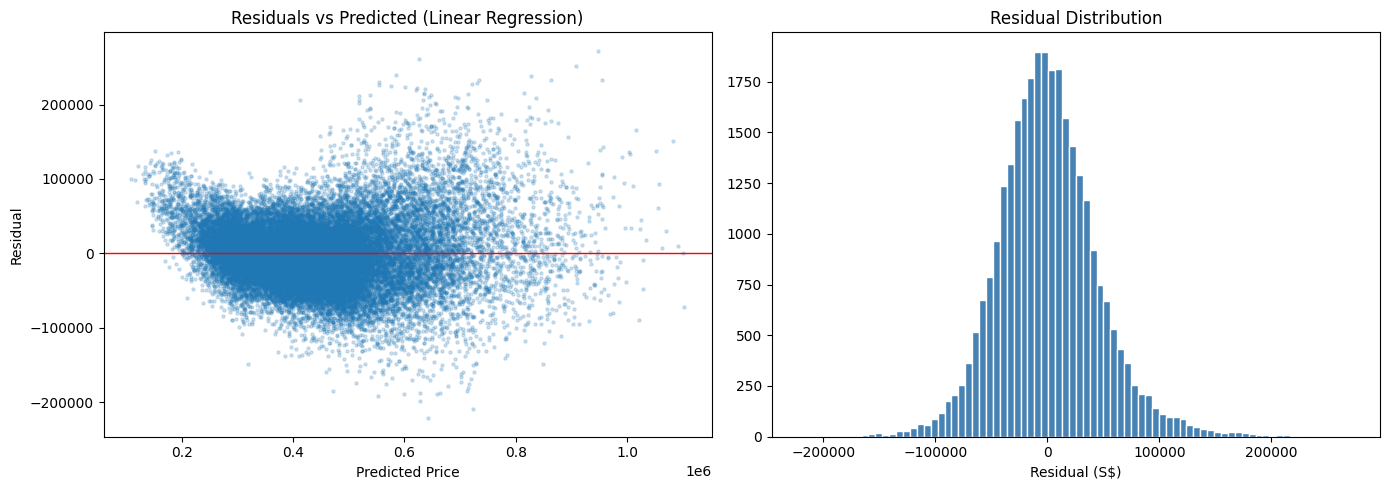

In [11]:
# Residual plot
residuals = y_va.values - val_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(val_pred, residuals, alpha=0.2, s=5)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted (Linear Regression)')

axes[1].hist(residuals, bins=80, edgecolor='white', color='steelblue')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (S$)')

fig.tight_layout()
fig.savefig('../outputs/plots/lr_baseline_residuals.png', dpi=120)
plt.show()

## 6. Data Leakage Check

Verify that `FeatureEngineer` does not use any information from the validation set.

In [12]:
# block_flat_psqm requires fit(X, y) — fit on train fold only to prevent leakage
fe_check = FeatureEngineer()
fe_check.fit(X_tr, y_tr)  # sees only training fold
X_tr_fe = fe_check.transform(X_tr)
X_va_fe = fe_check.transform(X_va)

print('block_flat_psqm: fitted on X_tr/y_tr only — val fold uses train-fold psqm means.')
print(f'Train FE shape: {X_tr_fe.shape}')
print(f'Val FE shape  : {X_va_fe.shape}')

# TargetEncoder uses CV internally — leakage-safe inside Pipeline
print('\nTargetEncoder: uses cv=5 internally to prevent target leakage in training.')

block_flat_psqm: fitted on X_tr/y_tr only — val fold uses train-fold psqm means.
Train FE shape: (120507, 63)
Val FE shape  : (30127, 63)

TargetEncoder: uses cv=5 internally to prevent target leakage in training.


## 7. 5-Fold KFold Cross-Validation (Baseline)

This is the **canonical evaluation metric** used across all notebooks.

In [13]:
print('Running 5-fold KFold CV on LinearRegression...')
mean_rmse, std_rmse = cv_score(lr_pipeline, X, y, n_splits=5)
print(f'LinearRegression CV RMSE: S${mean_rmse:,.0f} ± S${std_rmse:,.0f}')

Running 5-fold KFold CV on LinearRegression...
LinearRegression CV RMSE: S$45,561 ± S$271


In [14]:
# Save baseline pipeline
joblib.dump(lr_pipeline, MODEL_DIR / 'linear_regression_baseline.pkl')
print('Baseline pipeline saved.')

Baseline pipeline saved.


## 8. Feature Engineering Summary Table

| Feature | Source | Engineering | Rationale | Used in Model |
|---|---|---|---|---|
| `cbd_dist_m` | Lat/Lon | Haversine to Raffles Place | CBD proximity premium | Yes |
| `orchard_dist_m` | Lat/Lon | Haversine to Orchard | Secondary prestige hub | Yes |
| `floor_area_log` | `floor_area_sqm` | log1p | Normalise right skew | Yes |
| `mrt_dist_log` | `mrt_nearest_distance` | log1p | Diminishing returns | Yes |
| `mall_dist_log` | `Mall_Nearest_Distance` | log1p | Diminishing returns | No |
| `total_rental_units` | rental mix cols | Sum | Rental density signal | No |
| `rental_density` | `total_rental_units / total_dwelling_units` | Division | Rental proportion | Yes |
| `tranc_quarter` | `Tranc_Month` | ceil(month/3) | Seasonal quarter | Yes |
| `year_quarter` | Year + quarter | Year×10 + quarter | Continuous time index | Yes |
| `hdb_tranc_age` | `Tranc_Year − lease_commence_date` | Subtraction | Building age at transaction | Yes |
| `block_flat_psqm` | `resale_price / floor_area_sqm` | Mean per (block, flat_type, flat_model) | Location-adjusted price density | Yes |